Now we will visualize the scraped_news_augmented.csv like we did before

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("scraped_news_augmented.csv")  # reading scraped and augmented dataset

In [3]:
sns.set_style("whitegrid")   # visualization settings
plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
df.head(1)

,id,news_url,title,tweet_ids,label,clean_title,full_text,source
0,gossipcop-897560,https://www.elitedaily.com/p/the-2018-holiday-...,"The 2018 Holiday Gift For Your Partner, Based ...",936685609279737863\t936686125288185856\t936686...,0,2018 holiday gift partner based zodiac sign,"Since we're in the midst of Hanukkah, and Chri...",NaN


In [5]:
print(f"Total number of data: {len(df)}")  # total rows

Total number of data: 12228


In [8]:
def analyze_text_style(text):  # function for feature engineering
    text = str(text)  # ensuring that it is string
    if not isinstance(text, str) or len(text) < 5:
        return pd.Series([0, 0, 0, 0, 0, 0])

    words = text.split()  # to determine word count
    num_words = len(words) if len(words) > 0 else 1  # calculating total num of words

    # Sentiment Analysis
    try:
        blob = TextBlob(text)
        # Polarity: Measures emotionality  (between - 1.0 and + 1.0)
        sentiment = blob.sentiment.polarity  # emotion
        # Subjectivity: Measures objectivity (between - 1.0 and + 1.0)
        subjectivity = blob.sentiment.subjectivity # being subjective
    except:
        sentiment, subjectivity = 0, 0

    # Lexical Diversity
    unique_words = len(set(words))
    lexical_div = unique_words / num_words # unique words over num of words gives us the variety / diversity

    # Uppercase Ratio
    # quantifying the usage of capital letters in the news
    caps_count = sum(1 for c in text if c.isupper())
    caps_ratio = caps_count / len(text) if len(text) > 0 else 0  # count of upcase over total length

    # Punctuation Analysis (sensationalism)
    exclamation_count = text.count('!')

    # Return all extracted features as a Pandas Series for dataframe integration
    return pd.Series([num_words, sentiment, subjectivity, lexical_div, caps_ratio, exclamation_count])

In [9]:
df[['word_count', 'sentiment', 'subjectivity', 'lexical_div', 'caps_ratio', 'excl_count']] = df['full_text'].apply(analyze_text_style) # applying the function and creating columns

print("Function Completed. Columns are added.")
display(df.head(10))

Function Completed. Columns are added.


,id,news_url,title,tweet_ids,label,clean_title,full_text,source,word_count,sentiment,subjectivity,lexical_div,caps_ratio,excl_count
0,gossipcop-897560,https://www.elitedaily.com/p/the-2018-holiday-...,"The 2018 Holiday Gift For Your Partner, Based ...",936685609279737863\t936686125288185856\t936686...,0,2018 holiday gift partner based zodiac sign,"Since we're in the midst of Hanukkah, and Chri...",NaN,859.0,0.193464,0.513658,0.544820,0.022732,1.0
1,gossipcop-849067,https://www.refinery29.com/en-us/2017/05/15331...,Gen-Z Takes The MTV Movie & TV Awards Red Carp...,861370421601595392\t861370843342831616\t861370...,0,genz takes mtv movie awards red carpet storm,Entertainment\n\nHow Michaela Coel Pulled Off ...,NaN,37.0,0.000000,0.000000,1.000000,0.086207,0.0
2,gossipcop-875696,https://en.wikipedia.org/wiki/Look_What_You_Ma...,Look What You Made Me Do,901100538560991232\t901968588210393088\t901969...,0,look made,"2017 single by Taylor Swift\n\n""Look What You ...",NaN,5396.0,0.095222,0.403197,0.372683,0.036833,4.0
3,gossipcop-897997,https://www.yahoo.com/lifestyle/selena-gomez-w...,Selena Gomez Wore 6 Outfits in 1 Day — But She...,937821202885648389,0,selena gomez wore outfits day loved date night...,Selena Gomez and the Weeknd stepped out for da...,NaN,320.0,0.125938,0.390296,0.621875,0.049025,0.0
4,gossipcop-844614,https://www.biography.com/people/eric-roberts-...,Eric Roberts,854785357421957120,0,eric roberts,(1956-)\n\nSynopsis\n\nActor Eric Roberts was ...,NaN,747.0,0.018087,0.346635,0.519411,0.049755,1.0
5,gossipcop-892932,https://en.wikipedia.org/wiki/Paul_Anka,Jason Bateman Defends Wife Amanda Anka After S...,928879688545656832\t928880037142646784\t928880...,0,jason bateman defends wife amanda anka accuses...,Canadian-American singer and actor (born 1941)...,NaN,2567.0,0.122129,0.345941,0.460849,0.056263,3.0
6,gossipcop-891312,https://variety.com/2018/tv/news/robin-wright-...,Robin Wright on Kevin Spacey: ‘House of Cards’...,926417709457436672\t926417975086862337\t926418...,0,robin wright kevin spacey ‘house cards’ team ‘...,“House of Cards” star Robin Wright spoke out M...,NaN,191.0,0.028571,0.359524,0.717277,0.031667,0.0
7,politifact15158,https://web.archive.org/web/20180327213804/htt...,BREAKING: Irish superstar Saoirse Ronan dies a...,NaN,1,breaking irish superstar saoirse ronan dies on...,Irish and American actress Saoirse Ronan actre...,NaN,455.0,0.041349,0.444841,0.569231,0.041652,0.0
8,NaN,https://www.thebeaverton.com/2025/02/tampax-en...,Tampax encourages women to channel their rage ...,NaN,1,NaN,LOS ANGELES – With Donald Trump’s second presi...,The Beaverton,345.0,0.189572,0.459358,0.695652,0.024531,0.0
9,gossipcop-858874,https://www.usatoday.com/story/life/music/2017...,"After London terror attack, Ariana Grande conc...",871374813322989568\t871375034303959040\t871375...,0,london terror attack ariana grande concert man...,Hours after a second terror attack claimed the...,NaN,353.0,0.139903,0.370846,0.651558,0.043972,1.0


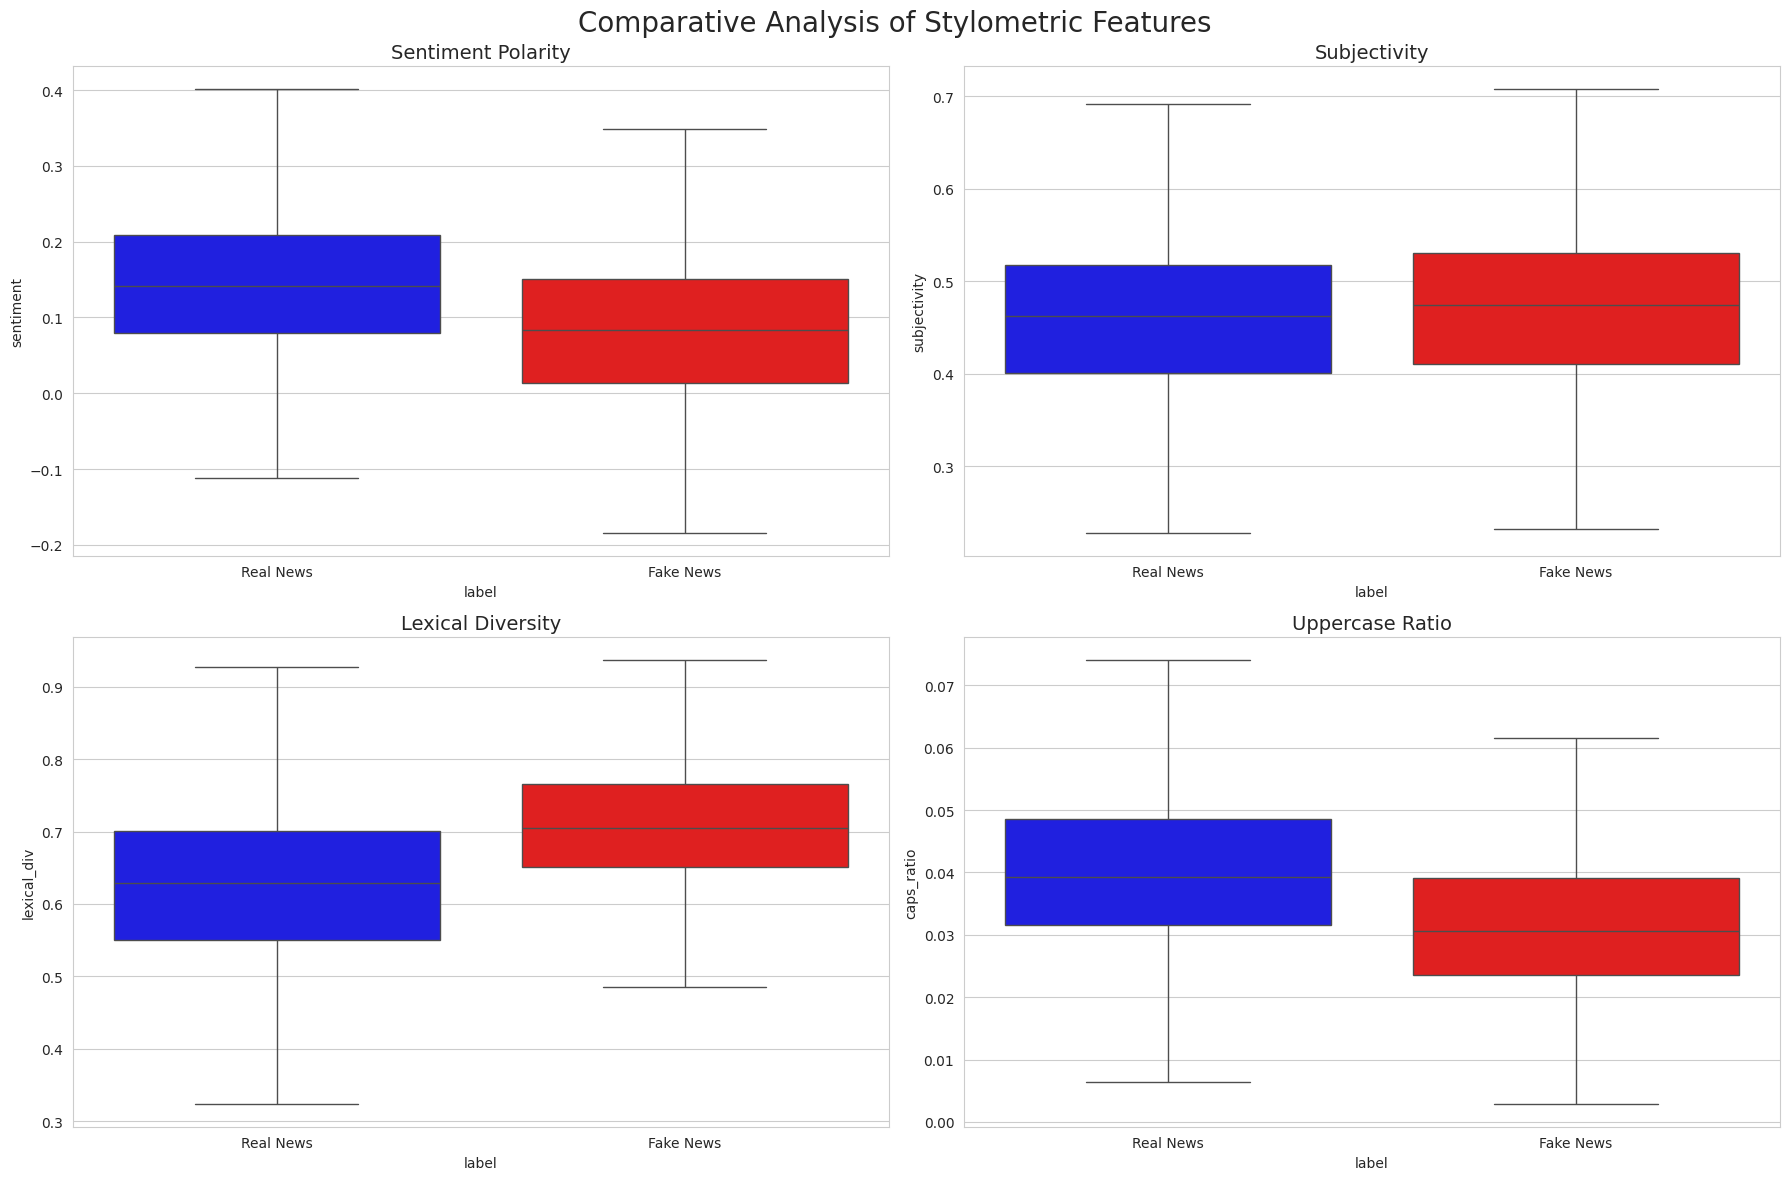

In [11]:
 # BOX PLOTS

df['label'] = df['label'].astype(str)
custom_palette = {'0': 'blue', '1': 'red'}
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# sentiment plot
sns.boxplot(x='label', y='sentiment', data=df, ax=axes[0, 0], palette=custom_palette, showfliers=False)
axes[0, 0].set_title('Sentiment Polarity', fontsize=14)
axes[0, 0].set_xticklabels(['Real News', 'Fake News'])

# Subjectivity plot
sns.boxplot(x='label', y='subjectivity', data=df, ax=axes[0, 1], palette=custom_palette, showfliers=False)
axes[0, 1].set_title('Subjectivity', fontsize=14)
axes[0, 1].set_xticklabels(['Real News', 'Fake News'])

# Lexical diversity
sns.boxplot(x='label', y='lexical_div', data=df, ax=axes[1, 0], palette=custom_palette, showfliers=False)
axes[1, 0].set_title('Lexical Diversity', fontsize=14)
axes[1, 0].set_xticklabels(['Real News', 'Fake News'])

# Caps Ratio
sns.boxplot(x='label', y='caps_ratio', data=df, ax=axes[1, 1], palette=custom_palette, showfliers=False)
axes[1, 1].set_title('Uppercase Ratio', fontsize=14)
axes[1, 1].set_xticklabels(['Real News', 'Fake News'])

plt.suptitle('Comparative Analysis of Stylometric Features', fontsize=20)
plt.tight_layout()
plt.show()

Lets display the source of top fake news from scraped articles using the source column we created.

In [12]:
# SOURCE ANALYSIS
from urllib.parse import urlparse

def extract_domain(url):
    try:
        if pd.isna(url): return "unknown"

        domain = urlparse(url).netloc.replace('www.', '')

        return domain if domain else "unknown"
    except:
        return "unknown"

if 'source' not in df.columns:
    print("Extracting source domains from URLs...")
    df['source'] = df['news_url'].apply(extract_domain)
    df.loc[df['source'] == "", 'source'] = "unknown source"





In [13]:
fake_data = df[df['label'].astype(str) == '1']  # filtering the dataset for fake news


top_fake_sources = fake_data['source'].value_counts().head(15)

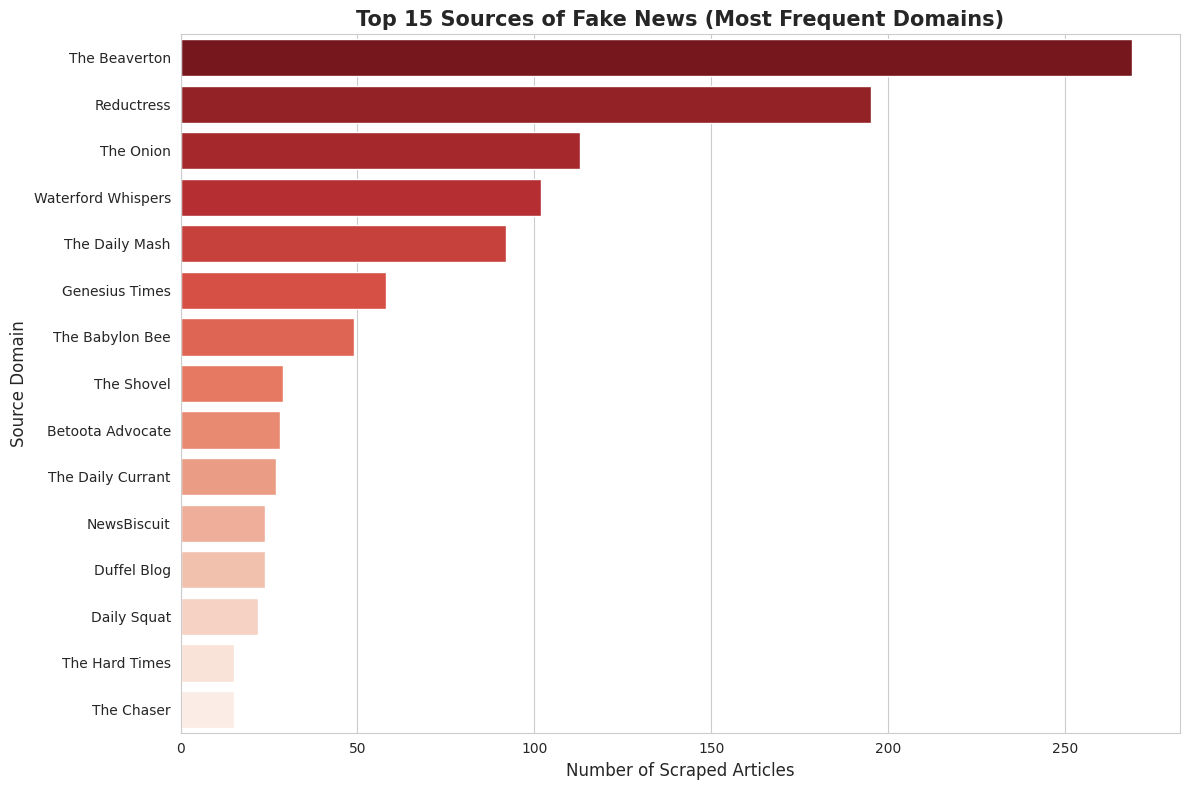


--- Top Fake News Sources Statistics ---
source
The Beaverton         269
Reductress            195
The Onion             113
Waterford Whispers    102
The Daily Mash         92
Genesius Times         58
The Babylon Bee        49
The Shovel             29
Betoota Advocate       28
The Daily Currant      27
NewsBiscuit            24
Duffel Blog            24
Daily Squat            22
The Hard Times         15
The Chaser             15
Name: count, dtype: int64


In [14]:
plt.figure(figsize=(12, 8))
sns.barplot(x=top_fake_sources.values, y=top_fake_sources.index, palette='Reds_r')


plt.title('Top 15 Sources of Fake News (Most Frequent Domains)', fontsize=15, fontweight='bold')
plt.xlabel('Number of Scraped Articles', fontsize=12)
plt.ylabel('Source Domain', fontsize=12)

plt.tight_layout()
plt.show()

print("\n--- Top Fake News Sources Statistics ---")
print(top_fake_sources)

We can see the distribution of top fake news sources are changed .

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

In [16]:
tfidf = TfidfVectorizer(max_features=3000, stop_words='english')  # get the most important 3k words
X_tfidf = tfidf.fit_transform(df['full_text'].astype(str))  # transform text to numbers

In [17]:
pca = PCA(n_components=2, random_state=42)  # carrying our data to second dimension (2D)
pca_result = pca.fit_transform(X_tfidf.toarray())

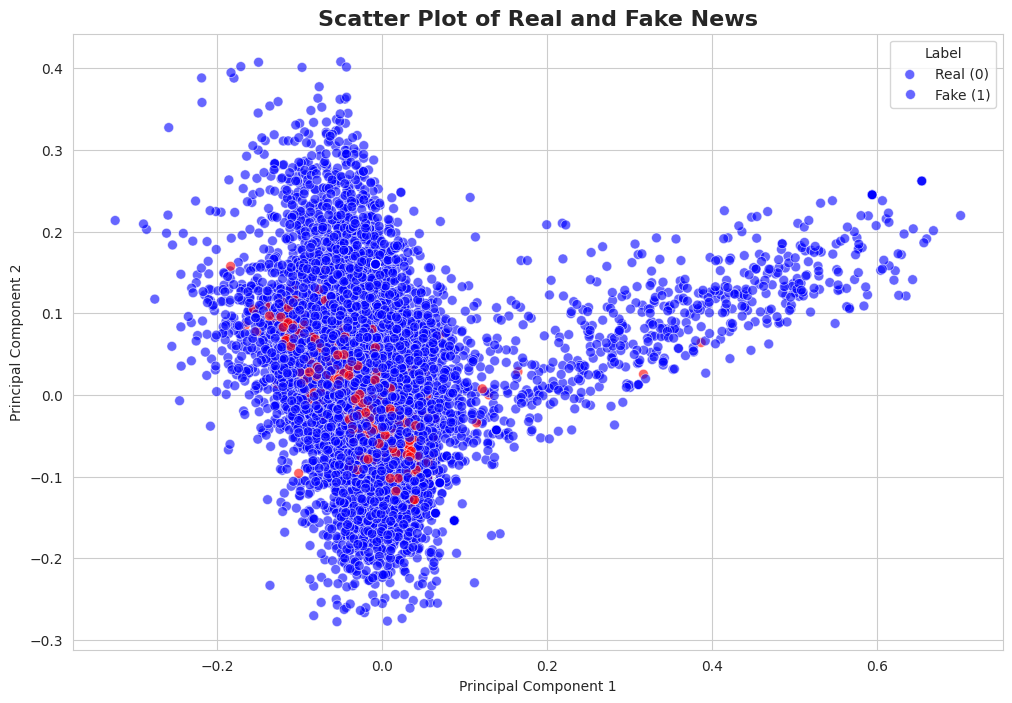

In [18]:
# SCATTER PLOT

plt.figure(figsize=(12, 8))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=df['label'].astype(str),
                palette={'0':'blue', '1':'red'}, alpha=0.6, s=50)

plt.title('Scatter Plot of Real and Fake News', fontsize=16, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Label', labels=['Real (0)', 'Fake (1)'])
plt.show()

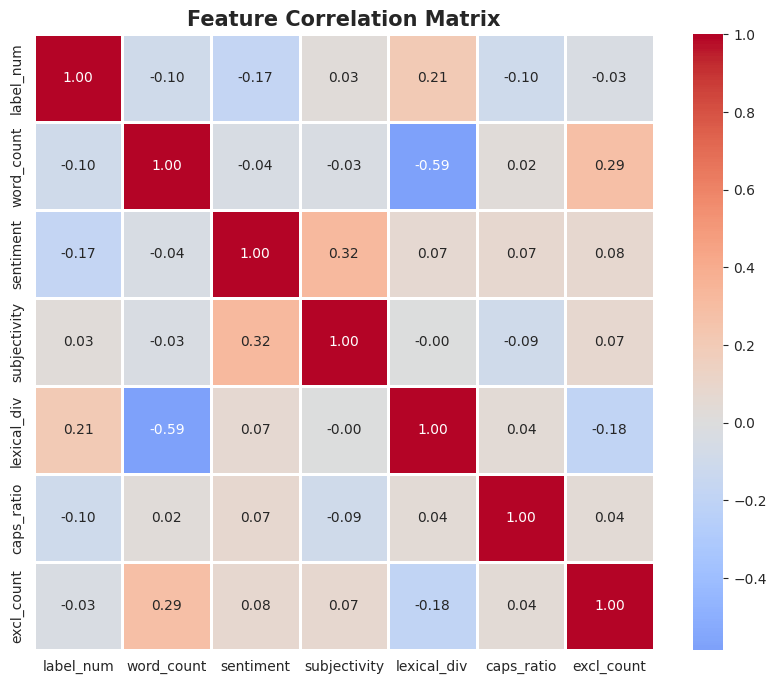

In [19]:
# Correlation Matrix
import seaborn as sns
import matplotlib.pyplot as plt
df['label_num'] = df['label'].astype(int)


corr_feats = ['label_num', 'word_count', 'sentiment', 'subjectivity', 'lexical_div', 'caps_ratio', 'excl_count']
corr_matrix = df[corr_feats].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=1)
plt.title('Feature Correlation Matrix', fontsize=15, fontweight='bold')
plt.show()

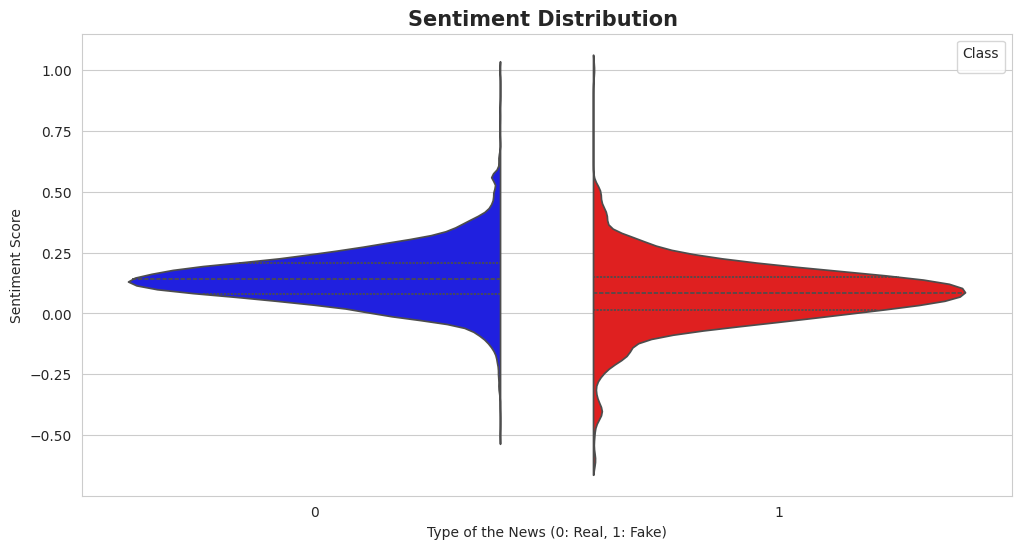

In [20]:
# VIOLIN PLOT

df['label_str'] = df['label'].astype(int).astype(str)

plt.figure(figsize=(12, 6))
sns.violinplot(x='label_str', y='sentiment', hue='label_str', data=df,
               palette={'0':'blue', '1':'red'}, split=True, inner="quart")

plt.title('Sentiment Distribution ', fontsize=15, fontweight='bold')
plt.xlabel('Type of the News (0: Real, 1: Fake)')
plt.ylabel('Sentiment Score')
plt.legend(title='Class')
plt.show()

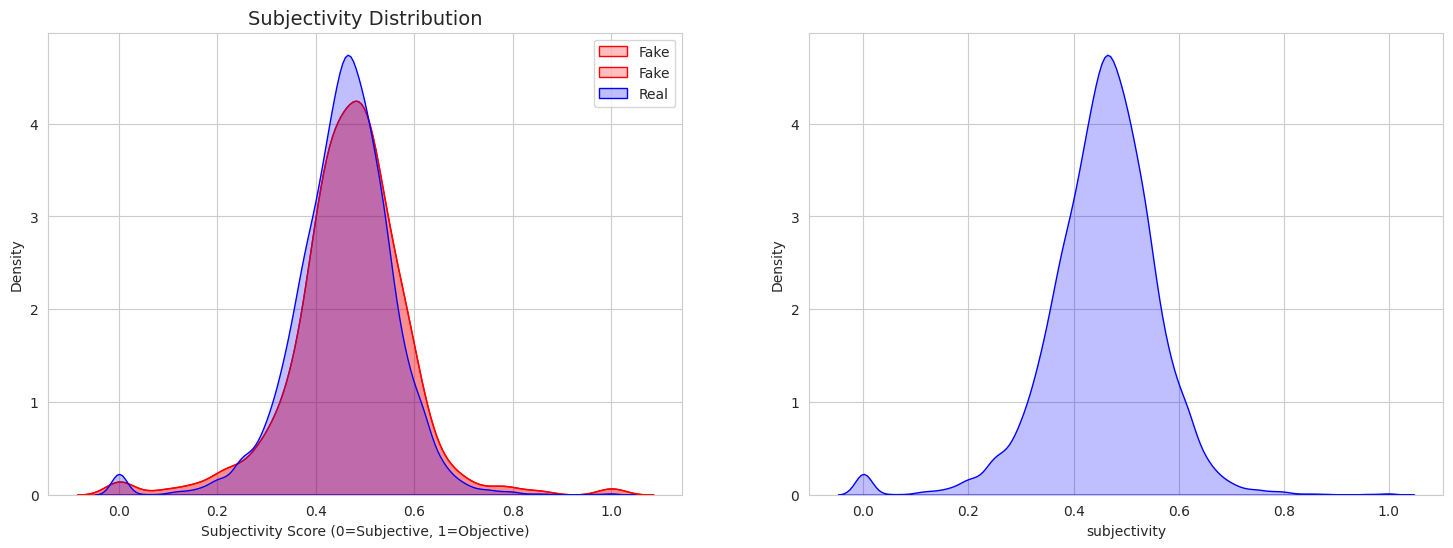

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.kdeplot(df[df['label']=='1']['subjectivity'], fill=True, color='red', label='Fake', ax=axes[0])
sns.kdeplot(df[df['label']=='0']['subjectivity'], fill=True, color='blue', label='Real', ax=axes[1])

sns.kdeplot(df[df['label']=='1']['subjectivity'], fill=True, color='red', label='Fake', ax=axes[0])
sns.kdeplot(df[df['label']=='0']['subjectivity'], fill=True, color='blue', label='Real', ax=axes[0])

axes[0].set_title('Subjectivity Distribution', fontsize=14)
axes[0].set_xlabel('Subjectivity Score (0=Subjective, 1=Objective)')
axes[0].legend()

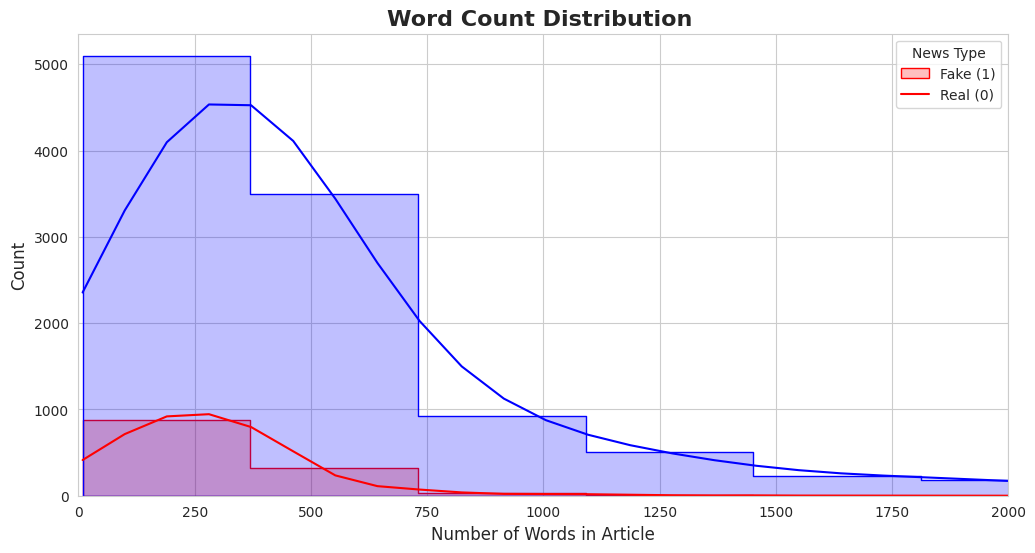


 Statistics of Word Count


         count        mean          std   min    25%    50%    75%      max
label                                                                      
0      10985.0  696.368776  1256.870198   9.0  234.0  395.0  651.0  18036.0
1       1243.0  294.699920   303.089206  21.0  162.0  260.0  390.5   8354.0


In [22]:
df['label'] = df['label'].astype(int)
if 'word_count' not in df.columns:
  target_col = 'full_text' if 'full_text' in df.columns else 'clean_title'
  df['word_count'] = df[target_col].fillna('').astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.histplot(data=df, x='word_count', hue='label', kde=True, element="step",
             palette={0:'blue', 1:'red'}, bins=50)

plt.title('Word Count Distribution ', fontsize=16, fontweight='bold')
plt.xlabel('Number of Words in Article', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.xlim(0, 2000) # x axis limit for graph

plt.legend(title='News Type', labels=['Fake (1)', 'Real (0)'])
plt.show()

  # printing statistics
print("\n Statistics of Word Count")
print("\n")
print(df.groupby('label')['word_count'].describe())

Lets get the final csv file for phase 1, the version that sentiment and other columns added.

In [23]:
df.to_csv("final_data.csv", index=False)